In [1]:
#%pip install plotly kaleido nbformat
#!pip uninstall ipywidgets plotly -y
#!pip install plotly ipywidgets --upgrade

In [2]:
import pandas as pd
import json

# Lire le fichier JSON et charger les données dans un DataFrame
with open('VA.json', 'r') as file:
    data = json.load(file)

df_A = pd.DataFrame(data)
with open('VE.json', 'r') as file:
    data = json.load(file)

df_E = pd.DataFrame(data)

In [3]:
# convertir les dates en datetime (format yy-mm-dd)
df_A['date'] = pd.to_datetime(df_A['date'], format='%y-%m-%d')
df_E['date'] = pd.to_datetime(df_E['date'], format='%y-%m-%d')

# extraire les prix numériques depuis la colonne 'value'
df_A['prix_va'] = df_A['value'].astype(str).str.extract(r'([\d\.,]+)')[0].str.replace(',', '.').astype(float)
df_E['prix_ve'] = df_E['value'].astype(str).str.extract(r'([\d\.,]+)')[0].str.replace(',', '.').astype(float)

# agréger par date (au cas où il y aurait plusieurs lignes pour une même date)
s_va = df_A.groupby('date')['prix_va'].mean()
s_ve = df_E.groupby('date')['prix_ve'].mean()

# concaténer pour obtenir un DataFrame avec index temporel et colonnes prix_va / prix_ve
df_merged = pd.concat([s_va, s_ve], axis=1).sort_index()
df_merged.index.name = 'date'

# affichage rapide
df_merged.head()

,prix_va,prix_ve
date,,
2003-11-14,8.8,4.08
2003-11-19,8.8,NaN
2003-11-21,NaN,4.08
2003-11-24,8.8,4.08
2003-11-25,NaN,4.15


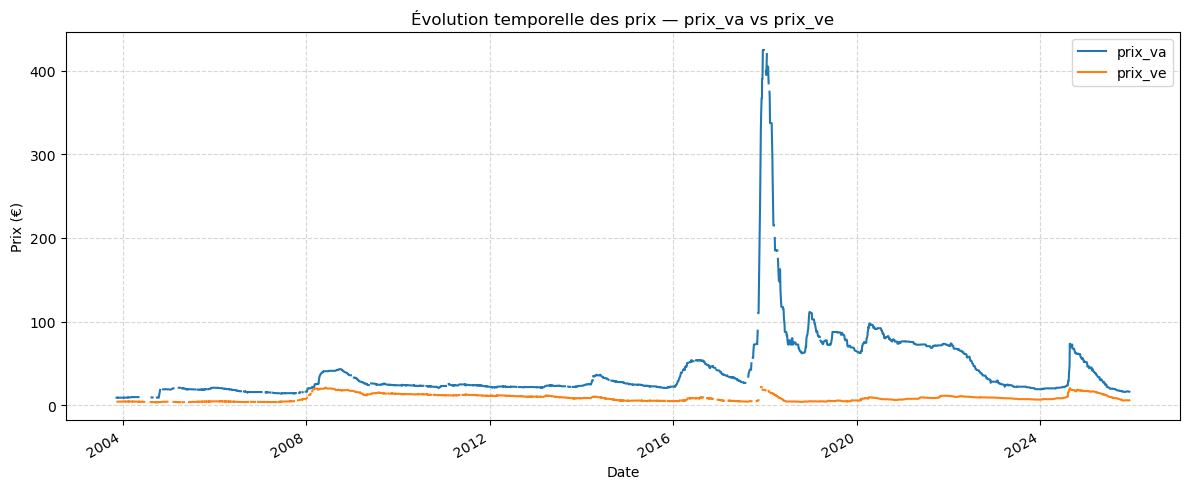

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(12,5))
ax = plt.gca()

# tracer les deux séries (index datetime)
df_merged[['prix_va', 'prix_ve']].plot(ax=ax)

ax.set_title("Évolution temporelle des prix — prix_va vs prix_ve")
ax.set_xlabel("Date")
ax.set_ylabel("Prix (€)")
ax.grid(True, linestyle="--", alpha=0.5)

# formatage des dates sur l'axe x
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

In [10]:
import plotly.io as pio
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np

# Préparer les données pour l'analyse
# Vérifier s'il y a une corrélation entre prix_va et prix_ve
# Utilise df_merged déjà présent dans le notebook.

# Préparer les paires (supprime les dates sans valeur pour l'une ou l'autre série)
pairs = df_merged.dropna(subset=['prix_va', 'prix_ve'])
print(f"Nombre de paires communes : {len(pairs)}")

# Corrélations simples
pearson = pairs['prix_va'].corr(pairs['prix_ve'], method='pearson')
spearman = pairs['prix_va'].corr(pairs['prix_ve'], method='spearman')
print(f"Corrélation Pearson : {pearson:.3f}")
print(f"Corrélation Spearman: {spearman:.3f}")

# Interprétation simple
if abs(pearson) >= 0.7:
    print("Interprétation (Pearson) : corrélation forte")
elif abs(pearson) >= 0.4:
    print("Interprétation (Pearson) : corrélation modérée")
else:
    print("Interprétation (Pearson) : corrélation faible ou inexistante")


# Forcer l'affichage
pio.renderers.default = 'vscode'

# Votre code
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=("Scatter prix_va vs prix_ve avec régression", 
                    "Corrélation glissante (fenêtre 180 jours)"),
    vertical_spacing=0.12
)

fig.add_trace(
    go.Scatter(
        x=x, y=y,
        mode='markers',
        marker=dict(size=5, opacity=0.6, color='blue'),
        name='Données',
        hovertemplate='prix_va: %{x:.2f}<br>prix_ve: %{y:.2f}<extra></extra>'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=np.sort(x),
        y=slope * np.sort(x) + intercept,
        mode='lines',
        line=dict(color='red', width=2),
        name=f'Régression: y={slope:.3f}x+{intercept:.3f}',
        hovertemplate='Régression<extra></extra>'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=rolling.index,
        y=rolling.values,
        mode='lines',
        line=dict(color='green', width=2),
        name='Corrélation glissante',
        hovertemplate='Date: %{x|%Y-%m-%d}<br>Corrélation: %{y:.3f}<extra></extra>'
    ),
    row=2, col=1
)

fig.add_hline(y=0, line_dash="dash", line_color="black", line_width=0.7, row=2, col=1)

fig.update_xaxes(title_text="prix_va", row=1, col=1)
fig.update_yaxes(title_text="prix_ve", row=1, col=1)
fig.update_xaxes(title_text="Date", row=2, col=1)
fig.update_yaxes(title_text="Corrélation", row=2, col=1)

fig.update_layout(
    title_text="Analyse interactive prix_va vs prix_ve",
    height=900,
    width=1000,
    hovermode='closest',
    showlegend=True
)

# Affichage avec plusieurs méthodes
print("Affichage du graphique...")
fig.show()

# Alternative : afficher dans le navigateur pour tester
print("Si rien ne s'affiche, tentative d'ouverture dans le navigateur...")
# Décommentez la ligne suivante si besoin :
# fig.show(renderer='browser')

Nombre de paires communes : 1712
Corrélation Pearson : 0.115
Corrélation Spearman: 0.162
Interprétation (Pearson) : corrélation faible ou inexistante
Affichage du graphique...


Si rien ne s'affiche, tentative d'ouverture dans le navigateur...


In [9]:
import plotly.io as pio
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np

# Utiliser le navigateur au lieu de vscode
pio.renderers.default = 'browser'

# Votre code complet
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=("Scatter prix_va vs prix_ve avec régression", 
                    "Corrélation glissante (fenêtre 180 jours)"),
    vertical_spacing=0.12
)

fig.add_trace(
    go.Scatter(
        x=x, y=y,
        mode='markers',
        marker=dict(size=5, opacity=0.6, color='blue'),
        name='Données',
        hovertemplate='prix_va: %{x:.2f}<br>prix_ve: %{y:.2f}<extra></extra>'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=np.sort(x),
        y=slope * np.sort(x) + intercept,
        mode='lines',
        line=dict(color='red', width=2),
        name=f'Régression: y={slope:.3f}x+{intercept:.3f}',
        hovertemplate='Régression<extra></extra>'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=rolling.index,
        y=rolling.values,
        mode='lines',
        line=dict(color='green', width=2),
        name='Corrélation glissante',
        hovertemplate='Date: %{x|%Y-%m-%d}<br>Corrélation: %{y:.3f}<extra></extra>'
    ),
    row=2, col=1
)

fig.add_hline(y=0, line_dash="dash", line_color="black", line_width=0.7, row=2, col=1)

fig.update_xaxes(title_text="prix_va", row=1, col=1)
fig.update_yaxes(title_text="prix_ve", row=1, col=1)
fig.update_xaxes(title_text="Date", row=2, col=1)
fig.update_yaxes(title_text="Corrélation", row=2, col=1)

fig.update_layout(
    title_text="Analyse interactive prix_va vs prix_ve",
    height=900,
    width=1000,
    hovermode='closest',
    showlegend=True
)

fig.show()  # S'ouvrira dans votre navigateur par défaut
print("✓ Graphique ouvert dans le navigateur")

✓ Graphique ouvert dans le navigateur


Nombre de paires communes : 1712
Corrélation Pearson : 0.115
Corrélation Spearman: 0.162
Interprétation (Pearson) : corrélation faible ou inexistante


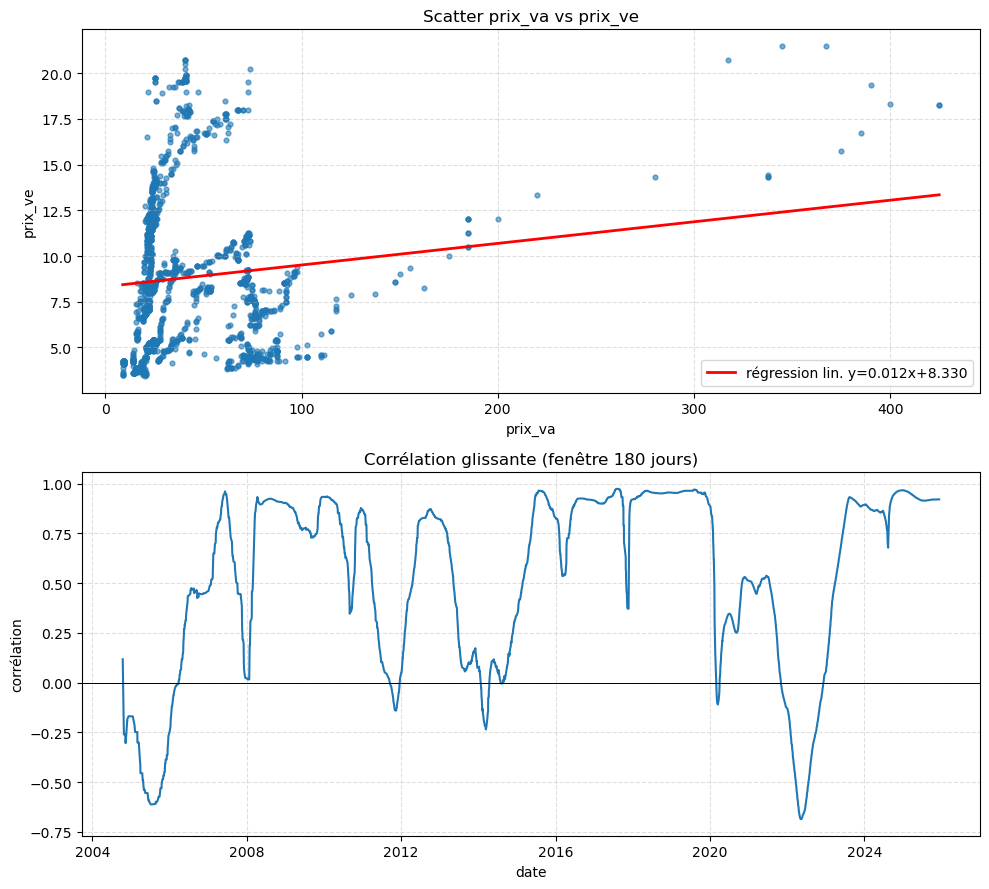

In [6]:
import numpy as np

# Vérifier s'il y a une corrélation entre prix_va et prix_ve
# Utilise df_merged déjà présent dans le notebook.

# Préparer les paires (supprime les dates sans valeur pour l'une ou l'autre série)
pairs = df_merged.dropna(subset=['prix_va', 'prix_ve'])
print(f"Nombre de paires communes : {len(pairs)}")

# Corrélations simples
pearson = pairs['prix_va'].corr(pairs['prix_ve'], method='pearson')
spearman = pairs['prix_va'].corr(pairs['prix_ve'], method='spearman')
print(f"Corrélation Pearson : {pearson:.3f}")
print(f"Corrélation Spearman: {spearman:.3f}")

# Interprétation simple
if abs(pearson) >= 0.7:
    print("Interprétation (Pearson) : corrélation forte")
elif abs(pearson) >= 0.4:
    print("Interprétation (Pearson) : corrélation modérée")
else:
    print("Interprétation (Pearson) : corrélation faible ou inexistante")

# Scatter plot + droite de régression
import matplotlib.pyplot as plt

x = pairs['prix_va'].values
y = pairs['prix_ve'].values
slope, intercept = np.polyfit(x, y, 1)
y_hat = slope * x + intercept

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9))

ax1.scatter(x, y, s=12, alpha=0.6)
ax1.plot(np.sort(x), slope * np.sort(x) + intercept, color='red', lw=2,
         label=f"régression lin. y={slope:.3f}x+{intercept:.3f}")
ax1.set_xlabel("prix_va")
ax1.set_ylabel("prix_ve")
ax1.set_title("Scatter prix_va vs prix_ve")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.4)

# Corrélation glissante pour voir l'évolution dans le temps (fenêtre en jours)
rolling = df_merged['prix_va'].rolling(window=180, min_periods=30).corr(df_merged['prix_ve'])
ax2.plot(rolling.index, rolling.values)
ax2.axhline(0, color='k', lw=0.7)
ax2.set_title("Corrélation glissante (fenêtre 180 jours)")
ax2.set_ylabel("corrélation")
ax2.set_xlabel("date")
ax2.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

ANALYSE DE CORRÉLATION : prix_va vs prix_ve

1. Corrélation de Pearson (linéaire) : 0.1150
2. Corrélation de Spearman (rang)     : 0.1625
3. Corrélation de Kendall (tau)       : 0.1278
4. Coefficient de détermination (R²)  : 0.0132
   → 1.32% de la variance de prix_ve est expliquée par prix_va

MATRICE DE CORRÉLATION
          prix_va   prix_ve
prix_va  1.000000  0.114975
prix_ve  0.114975  1.000000


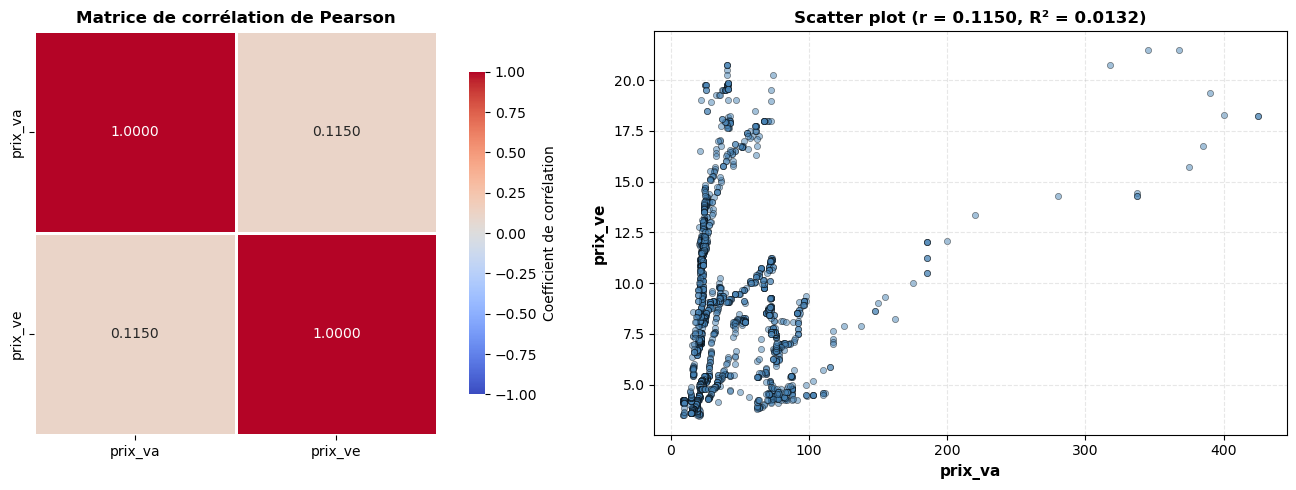


RÉSUMÉ DES CORRÉLATIONS
 Méthode   Valeur               Interprétation
 Pearson 0.114975         Corrélation linéaire
Spearman 0.162457 Corrélation monotone (rangs)
 Kendall 0.127771        Concordance des rangs
      R² 0.013219           Variance expliquée

ANALYSE DES DIFFÉRENCES

Différence moyenne (prix_ve - prix_va) : -33.85
Écart-type des différences              : 39.07
Différence médiane                      : -17.18
Différence min                          : -406.75
Différence max                          : -2.60


In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = df_merged.copy()

# %% [markdown]
# # Analyse de Corrélation : prix_va vs prix_ve
# 
# Cette analyse calcule différentes métriques de corrélation entre les prix VE (Voiture Électrique) 
# et VA (Voiture à Autonomie/Automatique).

# %% [markdown]
# ## 1. Types de corrélations calculées
# 
# ### Corrélation de Pearson (r)
# - **Définition** : Mesure la relation **linéaire** entre deux variables
# - **Valeurs** : Entre -1 (corrélation négative parfaite) et +1 (corrélation positive parfaite)
# - **Interprétation** : 
#   - r = 0 : Aucune corrélation linéaire
#   - 0 < |r| < 0.3 : Corrélation faible
#   - 0.3 ≤ |r| < 0.7 : Corrélation modérée
#   - 0.7 ≤ |r| ≤ 1 : Corrélation forte
# - **Sensible aux valeurs aberrantes** : Oui
# 
# ### Corrélation de Spearman (ρ)
# - **Définition** : Mesure la relation **monotone** (pas nécessairement linéaire) basée sur les rangs
# - **Avantage** : Robuste aux valeurs aberrantes et aux relations non-linéaires
# - **Usage** : Préférable quand la relation n'est pas strictement linéaire
# 
# ### Corrélation de Kendall (τ)
# - **Définition** : Mesure la concordance entre les rangs de deux variables
# - **Avantage** : Très robuste, bon pour petits échantillons
# - **Interprétation** : Probabilité de concordance vs discordance
# 
# ### Coefficient de détermination (R²)
# - **Définition** : R² = r² (carré de la corrélation de Pearson)
# - **Interprétation** : Pourcentage de variance d'une variable expliquée par l'autre
# - **Exemple** : R² = 0.64 signifie que 64% de la variabilité de prix_ve est expliquée par prix_va

# %%
print("=" * 60)
print("ANALYSE DE CORRÉLATION : prix_va vs prix_ve")
print("=" * 60)

# 1. Corrélation de Pearson (linéaire)
pearson_corr = df['prix_va'].corr(df['prix_ve'], method='pearson')
print(f"\n1. Corrélation de Pearson (linéaire) : {pearson_corr:.4f}")

# 2. Corrélation de Spearman (monotone, non linéaire)
spearman_corr = df['prix_va'].corr(df['prix_ve'], method='spearman')
print(f"2. Corrélation de Spearman (rang)     : {spearman_corr:.4f}")

# 3. Corrélation de Kendall
kendall_corr = df['prix_va'].corr(df['prix_ve'], method='kendall')
print(f"3. Corrélation de Kendall (tau)       : {kendall_corr:.4f}")

# 4. Coefficient de détermination (R²)
r_squared = pearson_corr ** 2
print(f"4. Coefficient de détermination (R²)  : {r_squared:.4f}")
print(f"   → {r_squared*100:.2f}% de la variance de prix_ve est expliquée par prix_va")

# %% [markdown]
# ## 2. Interprétation des résultats
# 
# ### Force de la corrélation (selon Pearson)
# - **Si |r| < 0.3** : Corrélation faible → peu de relation linéaire
# - **Si 0.3 ≤ |r| < 0.7** : Corrélation modérée → relation linéaire moyenne
# - **Si |r| ≥ 0.7** : Corrélation forte → forte relation linéaire
# 
# ### Comparaison Pearson vs Spearman
# - **Si Pearson ≈ Spearman** : La relation est linéaire
# - **Si Spearman > Pearson** : La relation est monotone mais non-linéaire
# - **Si très différents** : Présence possible de valeurs aberrantes ou relation complexe

# %%
# Matrice de corrélation complète
correlation_matrix = df[['prix_va', 'prix_ve']].corr()

print("\n" + "=" * 60)
print("MATRICE DE CORRÉLATION")
print("=" * 60)
print(correlation_matrix)

# %% [markdown]
# ## 3. Visualisations
# 
# ### Graphique 1 : Heatmap de corrélation
# - Représentation visuelle de la matrice de corrélation
# - **Rouge** : Corrélation négative
# - **Bleu** : Corrélation positive
# - **Blanc** : Pas de corrélation
# 
# ### Graphique 2 : Scatter plot
# - Visualisation directe de la relation entre prix_va et prix_ve
# - Permet d'identifier visuellement la linéarité et les valeurs aberrantes

# %%
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de corrélation
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.4f', 
            cmap='coolwarm', 
            center=0,
            vmin=-1, vmax=1,  # Échelle fixe de -1 à 1
            square=True, 
            linewidths=2,
            cbar_kws={"shrink": 0.8, "label": "Coefficient de corrélation"},
            ax=axes[0])
axes[0].set_title('Matrice de corrélation de Pearson', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('')

# Pairplot simplifié
axes[1].scatter(df['prix_va'], df['prix_ve'], alpha=0.5, s=20, c='steelblue', edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('prix_va', fontsize=11, fontweight='bold')
axes[1].set_ylabel('prix_ve', fontsize=11, fontweight='bold')
axes[1].set_title(f'Scatter plot (r = {pearson_corr:.4f}, R² = {r_squared:.4f})', 
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, linestyle='--')

# Ajouter la ligne de régression si corrélation significative
if abs(pearson_corr) > 0.3:
    z = np.polyfit(df['prix_va'], df['prix_ve'], 1)
    p = np.poly1d(z)
    axes[1].plot(df['prix_va'], p(df['prix_va']), "r--", linewidth=2, alpha=0.7, 
                 label=f'Régression linéaire')
    axes[1].legend()

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 4. Résumé statistique
# 
# Le tableau ci-dessous fournit un résumé complet des corrélations calculées :

# %%
# Créer un résumé en DataFrame
summary = pd.DataFrame({
    'Méthode': ['Pearson', 'Spearman', 'Kendall', 'R²'],
    'Valeur': [pearson_corr, spearman_corr, kendall_corr, r_squared],
    'Interprétation': [
        'Corrélation linéaire',
        'Corrélation monotone (rangs)',
        'Concordance des rangs',
        'Variance expliquée'
    ]
})

print("\n" + "=" * 60)
print("RÉSUMÉ DES CORRÉLATIONS")
print("=" * 60)
print(summary.to_string(index=False))

# %% [markdown]
# ## 5. Conclusion
# 
# ### Points clés à retenir :
# 
# 1. **Force de la relation** : Basée sur le coefficient de Pearson
#    - Forte si |r| ≥ 0.7
#    - Modérée si 0.3 ≤ |r| < 0.7
#    - Faible si |r| < 0.3
# 
# 2. **Nature de la relation** : 
#    - Linéaire si Pearson ≈ Spearman
#    - Non-linéaire si Spearman significativement différent
# 
# 3. **Pouvoir prédictif** : R² indique la proportion de variance expliquée
# 
# 4. **Robustesse** : Spearman et Kendall sont moins sensibles aux valeurs aberrantes
# 
# ### Recommandations d'analyse :
# - Si corrélation faible : Chercher d'autres variables explicatives
# - Si corrélation forte : Approfondir l'analyse de causalité
# - Toujours visualiser les données (scatter plot) avant de conclure

# %%
# Analyse supplémentaire : distribution des différences
print("\n" + "=" * 60)
print("ANALYSE DES DIFFÉRENCES")
print("=" * 60)

diff = df['prix_ve'] - df['prix_va']
print(f"\nDifférence moyenne (prix_ve - prix_va) : {diff.mean():.2f}")
print(f"Écart-type des différences              : {diff.std():.2f}")
print(f"Différence médiane                      : {diff.median():.2f}")
print(f"Différence min                          : {diff.min():.2f}")
print(f"Différence max                          : {diff.max():.2f}")

# %% [markdown]
# ---
# **Note** : Ces analyses supposent que les données sont continues et que les observations sont indépendantes.
# Pour des conclusions causales, des analyses plus approfondies seraient nécessaires.

In [15]:
df

,prix_va,prix_ve
date,,
2003-11-14,8.80,4.08
2003-11-19,8.80,NaN
2003-11-21,NaN,4.08
2003-11-24,8.80,4.08
2003-11-25,NaN,4.15
...,...,...
2025-11-25,16.25,5.70
2025-11-27,16.50,5.50
2025-12-02,16.25,5.50


ANALYSE DE CORRÉLATION : prix_va vs prix_ve

1. Corrélation de Pearson (linéaire) : 0.1150
2. Corrélation de Spearman (rang)     : 0.1625
3. Corrélation de Kendall (tau)       : 0.1278
4. Coefficient de détermination (R²)  : 0.0132
   → 1.32% de la variance de prix_ve est expliquée par prix_va

MATRICE DE CORRÉLATION
          prix_va   prix_ve
prix_va  1.000000  0.114975
prix_ve  0.114975  1.000000


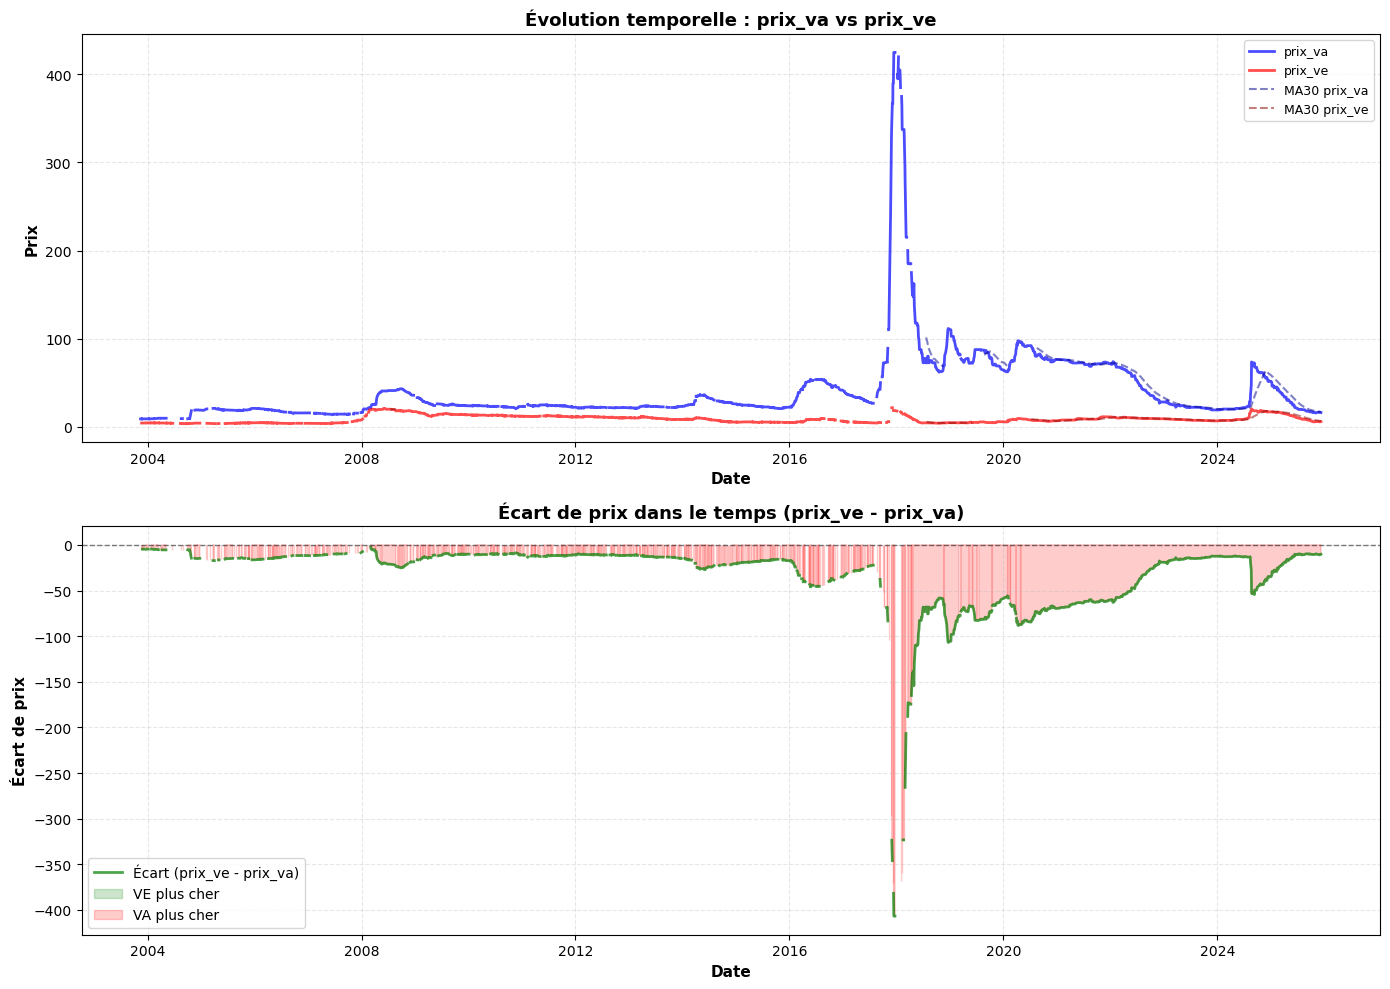


STATISTIQUES SUR L'ÉCART DE PRIX
Écart moyen (prix_ve - prix_va)       : -33.85
Écart médian                          : -17.18
Écart-type                            : 39.07
Écart minimum                         : -406.75
Écart maximum                         : -2.60
% du temps où prix_ve > prix_va       : 0.0%
% du temps où prix_ve < prix_va       : 71.5%

STATISTIQUES SUR LES RENDEMENTS (variations en %)

--- Prix VA ---
Rendement moyen           : 0.0782%
Rendement médian          : 0.0000%
Volatilité (écart-type)   : 3.6350%
Rendement min             : -21.4286%
Rendement max             : 98.3607%

--- Prix VE ---
Rendement moyen           : 0.0967%
Rendement médian          : 0.0000%
Volatilité (écart-type)   : 5.8773%
Rendement min             : -16.0000%
Rendement max             : 262.1291%

--- Comparaison ---
Ratio volatilité VE/VA    : 1.62
→ Prix VE est 1.62x plus volatil que prix VA


/var/folders/vw/2g_98rts7tzczmvh5hqt_qn00000gn/T/ipykernel_98649/1750156346.py:180: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.

/var/folders/vw/2g_98rts7tzczmvh5hqt_qn00000gn/T/ipykernel_98649/1750156346.py:181: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



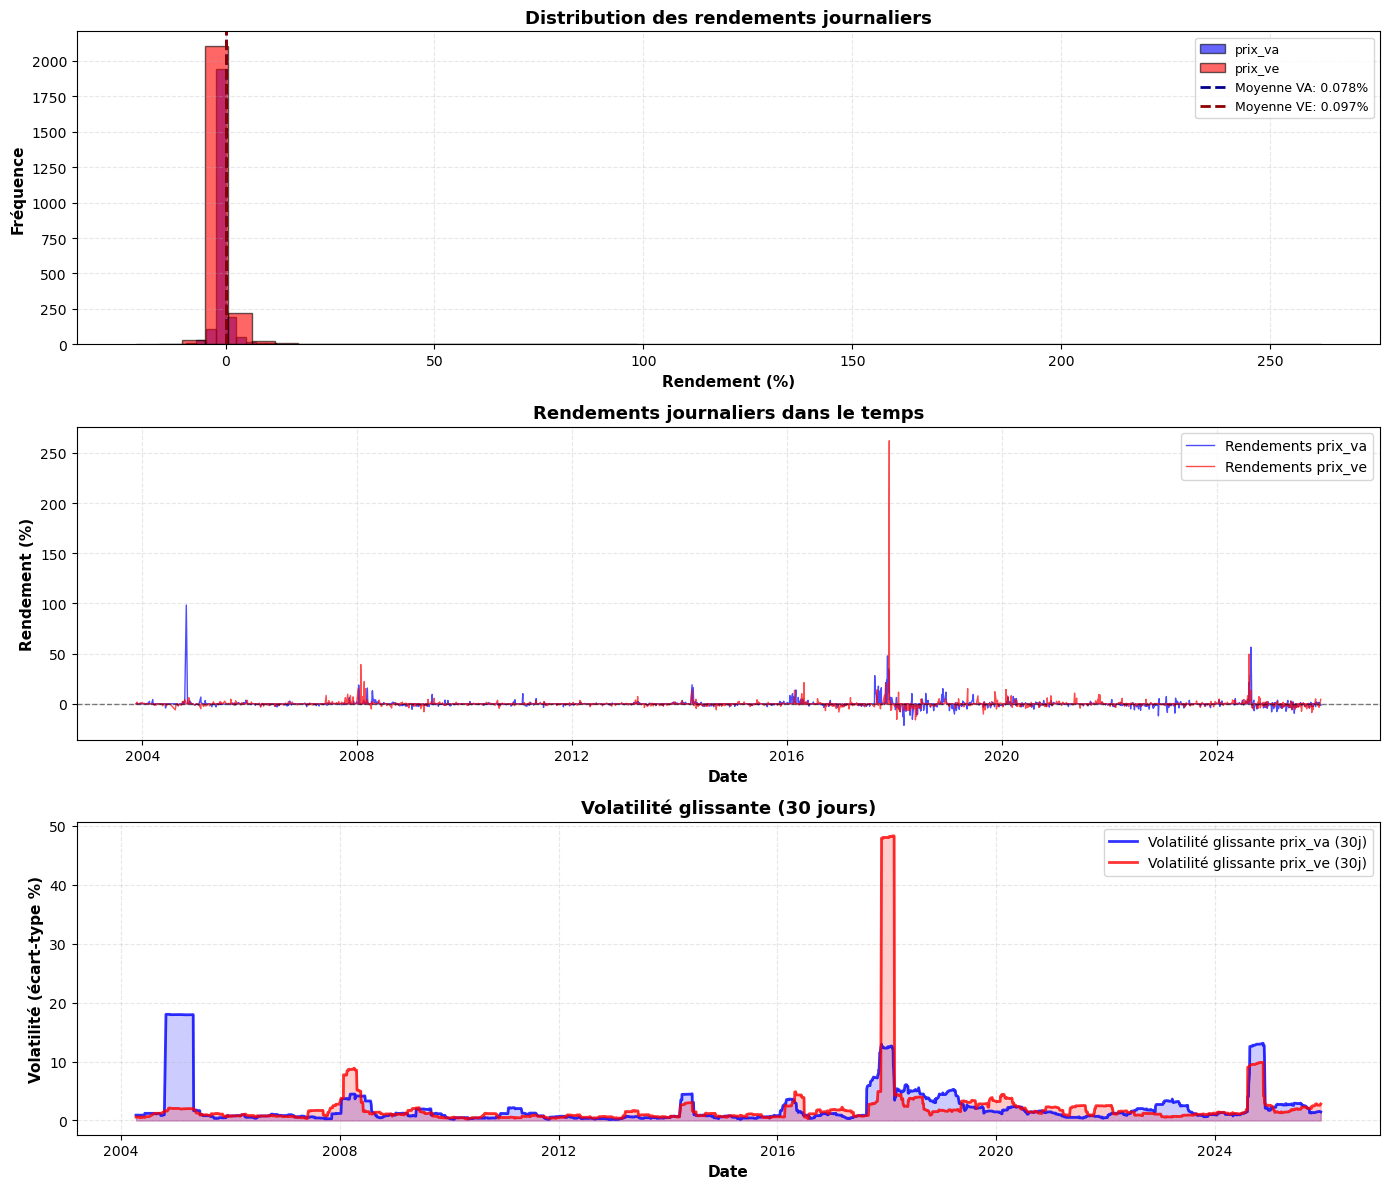


CORRÉLATION DES RENDEMENTS
Corrélation des rendements VA-VE : 0.2420

Interprétation :
→ Les variations de prix sont faiblement corrélées
→ Les deux prix évoluent de manière relativement indépendante


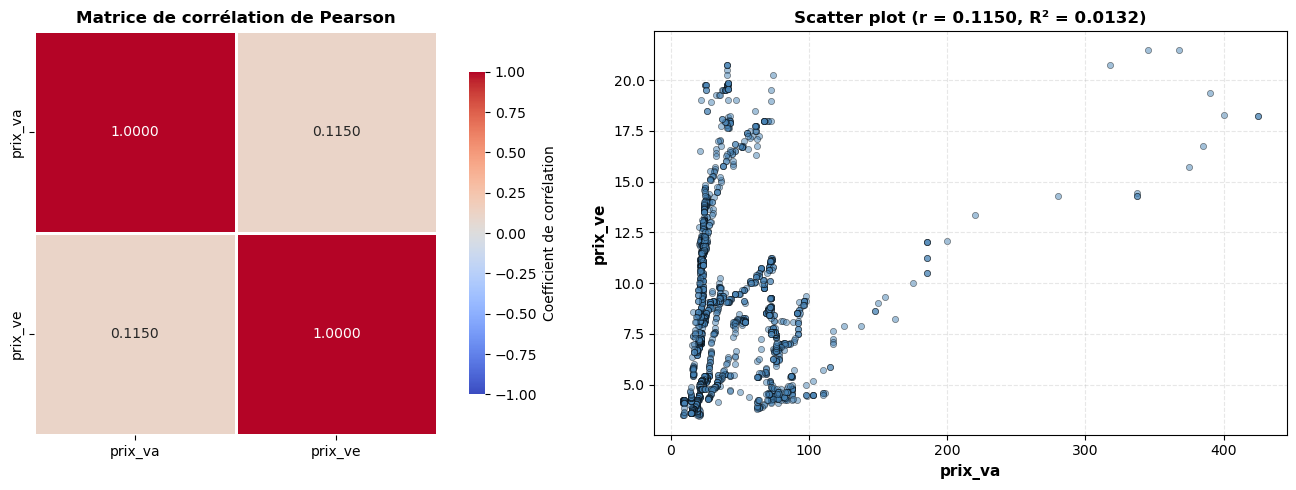


RÉSUMÉ DES CORRÉLATIONS
 Méthode   Valeur               Interprétation
 Pearson 0.114975         Corrélation linéaire
Spearman 0.162457 Corrélation monotone (rangs)
 Kendall 0.127771        Concordance des rangs
      R² 0.013219           Variance expliquée

RÉSUMÉ DE LA VOLATILITÉ
Variable  Volatilité (%)  Rendement moyen (%)  Rendement min (%)  Rendement max (%)
 prix_va        3.635045             0.078227         -21.428571          98.360656
 prix_ve        5.877271             0.096700         -16.000000         262.129145

ANALYSE DES DIFFÉRENCES

Différence moyenne (prix_ve - prix_va) : -33.85
Écart-type des différences              : 39.07
Différence médiane                      : -17.18
Différence min                          : -406.75
Différence max                          : -2.60


In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# %% [markdown]
# # Analyse de Corrélation : prix_va vs prix_ve
# 
# Cette analyse calcule différentes métriques de corrélation entre les prix VE (Voiture Électrique) 
# et VA (Voiture à Autonomie/Automatique).

# %% [markdown]
# ## 1. Types de corrélations calculées
# 
# ### Corrélation de Pearson (r)
# - **Définition** : Mesure la relation **linéaire** entre deux variables
# - **Valeurs** : Entre -1 (corrélation négative parfaite) et +1 (corrélation positive parfaite)
# - **Interprétation** : 
#   - r = 0 : Aucune corrélation linéaire
#   - 0 < |r| < 0.3 : Corrélation faible
#   - 0.3 ≤ |r| < 0.7 : Corrélation modérée
#   - 0.7 ≤ |r| ≤ 1 : Corrélation forte
# - **Sensible aux valeurs aberrantes** : Oui
# 
# ### Corrélation de Spearman (ρ)
# - **Définition** : Mesure la relation **monotone** (pas nécessairement linéaire) basée sur les rangs
# - **Avantage** : Robuste aux valeurs aberrantes et aux relations non-linéaires
# - **Usage** : Préférable quand la relation n'est pas strictement linéaire
# 
# ### Corrélation de Kendall (τ)
# - **Définition** : Mesure la concordance entre les rangs de deux variables
# - **Avantage** : Très robuste, bon pour petits échantillons
# - **Interprétation** : Probabilité de concordance vs discordance
# 
# ### Coefficient de détermination (R²)
# - **Définition** : R² = r² (carré de la corrélation de Pearson)
# - **Interprétation** : Pourcentage de variance d'une variable expliquée par l'autre
# - **Exemple** : R² = 0.64 signifie que 64% de la variabilité de prix_ve est expliquée par prix_va

# %%
print("=" * 60)
print("ANALYSE DE CORRÉLATION : prix_va vs prix_ve")
print("=" * 60)

# 1. Corrélation de Pearson (linéaire)
pearson_corr = df['prix_va'].corr(df['prix_ve'], method='pearson')
print(f"\n1. Corrélation de Pearson (linéaire) : {pearson_corr:.4f}")

# 2. Corrélation de Spearman (monotone, non linéaire)
spearman_corr = df['prix_va'].corr(df['prix_ve'], method='spearman')
print(f"2. Corrélation de Spearman (rang)     : {spearman_corr:.4f}")

# 3. Corrélation de Kendall
kendall_corr = df['prix_va'].corr(df['prix_ve'], method='kendall')
print(f"3. Corrélation de Kendall (tau)       : {kendall_corr:.4f}")

# 4. Coefficient de détermination (R²)
r_squared = pearson_corr ** 2
print(f"4. Coefficient de détermination (R²)  : {r_squared:.4f}")
print(f"   → {r_squared*100:.2f}% de la variance de prix_ve est expliquée par prix_va")

# %% [markdown]
# ## 2. Interprétation des résultats
# 
# ### Force de la corrélation (selon Pearson)
# - **Si |r| < 0.3** : Corrélation faible → peu de relation linéaire
# - **Si 0.3 ≤ |r| < 0.7** : Corrélation modérée → relation linéaire moyenne
# - **Si |r| ≥ 0.7** : Corrélation forte → forte relation linéaire
# 
# ### Comparaison Pearson vs Spearman
# - **Si Pearson ≈ Spearman** : La relation est linéaire
# - **Si Spearman > Pearson** : La relation est monotone mais non-linéaire
# - **Si très différents** : Présence possible de valeurs aberrantes ou relation complexe

# %%
# Matrice de corrélation complète
correlation_matrix = df[['prix_va', 'prix_ve']].corr()

print("\n" + "=" * 60)
print("MATRICE DE CORRÉLATION")
print("=" * 60)
print(correlation_matrix)

# %% [markdown]
# ## 3. Évolution temporelle des prix
# 
# ### Graphique temporel
# - Visualisation de l'évolution des prix VE et VA dans le temps
# - Permet d'identifier :
#   - Les **tendances** : croissance, décroissance, stagnation
#   - Les **cycles** : variations saisonnières ou périodiques
#   - Les **événements** : chocs, ruptures, anomalies
#   - La **volatilité** : stabilité ou instabilité des prix
# - **Écart prix_ve - prix_va** : Différence entre les deux prix dans le temps
#   - Positif : prix_ve > prix_va (VE plus cher)
#   - Négatif : prix_ve < prix_va (VA plus cher)

# %%
# Créer une figure avec 2 sous-graphiques
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Graphique 1 : Évolution temporelle des deux prix
axes[0].plot(df.index, df['prix_va'], label='prix_va', linewidth=2, color='blue', alpha=0.7)
axes[0].plot(df.index, df['prix_ve'], label='prix_ve', linewidth=2, color='red', alpha=0.7)
axes[0].set_xlabel('Date', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Prix', fontsize=11, fontweight='bold')
axes[0].set_title('Évolution temporelle : prix_va vs prix_ve', fontsize=13, fontweight='bold')
axes[0].legend(loc='best', fontsize=10)
axes[0].grid(True, alpha=0.3, linestyle='--')

# Ajouter les moyennes mobiles (optionnel)
if len(df) > 30:
    window = min(30, len(df) // 10)  # Fenêtre adaptative
    ma_va = df['prix_va'].rolling(window=window).mean()
    ma_ve = df['prix_ve'].rolling(window=window).mean()
    axes[0].plot(df.index, ma_va, '--', linewidth=1.5, color='darkblue', 
                 alpha=0.5, label=f'MA{window} prix_va')
    axes[0].plot(df.index, ma_ve, '--', linewidth=1.5, color='darkred', 
                 alpha=0.5, label=f'MA{window} prix_ve')
    axes[0].legend(loc='best', fontsize=9)

# Graphique 2 : Écart entre les prix (prix_ve - prix_va)
ecart = df['prix_ve'] - df['prix_va']
axes[1].plot(df.index, ecart, linewidth=2, color='green', alpha=0.7, label='Écart (prix_ve - prix_va)')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1].fill_between(df.index, ecart, 0, where=(ecart >= 0), 
                      color='green', alpha=0.2, label='VE plus cher')
axes[1].fill_between(df.index, ecart, 0, where=(ecart < 0), 
                      color='red', alpha=0.2, label='VA plus cher')
axes[1].set_xlabel('Date', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Écart de prix', fontsize=11, fontweight='bold')
axes[1].set_title('Écart de prix dans le temps (prix_ve - prix_va)', fontsize=13, fontweight='bold')
axes[1].legend(loc='best', fontsize=10)
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Statistiques sur l'écart
print("\n" + "=" * 60)
print("STATISTIQUES SUR L'ÉCART DE PRIX")
print("=" * 60)
print(f"Écart moyen (prix_ve - prix_va)       : {ecart.mean():.2f}")
print(f"Écart médian                          : {ecart.median():.2f}")
print(f"Écart-type                            : {ecart.std():.2f}")
print(f"Écart minimum                         : {ecart.min():.2f}")
print(f"Écart maximum                         : {ecart.max():.2f}")
print(f"% du temps où prix_ve > prix_va       : {(ecart > 0).sum() / len(ecart) * 100:.1f}%")
print(f"% du temps où prix_ve < prix_va       : {(ecart < 0).sum() / len(ecart) * 100:.1f}%")

# %% [markdown]
# ## 4. Analyse de volatilité
# 
# ### Qu'est-ce que la volatilité ?
# - **Définition** : Mesure de la dispersion des rendements (variation des prix) autour de leur moyenne
# - **Importance** : Indicateur de risque et d'incertitude sur les prix
# - **Interprétation** :
#   - Volatilité élevée = Prix instables, risque élevé, grandes variations
#   - Volatilité faible = Prix stables, risque faible, petites variations
# 
# ### Méthodes de calcul :
# 
# #### 1. Rendements (Returns)
# - **Définition** : Variation relative du prix entre deux périodes
# - **Formule** : return_t = (prix_t - prix_{t-1}) / prix_{t-1} × 100
# - **Interprétation** : Pourcentage de variation du prix
# 
# #### 2. Volatilité (Écart-type des rendements)
# - **Définition** : Écart-type des rendements sur une période
# - **Usage** : Mesure la dispersion des variations de prix
# - **Plus l'écart-type est élevé, plus les prix sont volatils**
# 
# #### 3. Volatilité glissante (Rolling Volatility)
# - **Définition** : Volatilité calculée sur une fenêtre mobile (ex: 30 jours)
# - **Avantage** : Permet de voir comment la volatilité évolue dans le temps
# - **Usage** : Identifier les périodes de forte/faible volatilité

# %%
# Calcul des rendements (variations en pourcentage)
returns_va = df['prix_va'].pct_change() * 100  # En pourcentage
returns_ve = df['prix_ve'].pct_change() * 100  # En pourcentage

# Supprimer la première valeur NaN
returns_va = returns_va.dropna()
returns_ve = returns_ve.dropna()

# Statistiques sur les rendements
print("\n" + "=" * 60)
print("STATISTIQUES SUR LES RENDEMENTS (variations en %)")
print("=" * 60)

print("\n--- Prix VA ---")
print(f"Rendement moyen           : {returns_va.mean():.4f}%")
print(f"Rendement médian          : {returns_va.median():.4f}%")
print(f"Volatilité (écart-type)   : {returns_va.std():.4f}%")
print(f"Rendement min             : {returns_va.min():.4f}%")
print(f"Rendement max             : {returns_va.max():.4f}%")

print("\n--- Prix VE ---")
print(f"Rendement moyen           : {returns_ve.mean():.4f}%")
print(f"Rendement médian          : {returns_ve.median():.4f}%")
print(f"Volatilité (écart-type)   : {returns_ve.std():.4f}%")
print(f"Rendement min             : {returns_ve.min():.4f}%")
print(f"Rendement max             : {returns_ve.max():.4f}%")

# Comparaison
print("\n--- Comparaison ---")
ratio_vol = returns_ve.std() / returns_va.std()
print(f"Ratio volatilité VE/VA    : {ratio_vol:.2f}")
if ratio_vol > 1:
    print(f"→ Prix VE est {ratio_vol:.2f}x plus volatil que prix VA")
else:
    print(f"→ Prix VA est {1/ratio_vol:.2f}x plus volatil que prix VE")

# %%
# Calcul de la volatilité glissante (rolling volatility)
if len(df) > 30:
    window_vol = min(30, len(df) // 10)  # Fenêtre adaptative
else:
    window_vol = max(5, len(df) // 5)

rolling_vol_va = returns_va.rolling(window=window_vol).std()
rolling_vol_ve = returns_ve.rolling(window=window_vol).std()

# Créer une figure avec 3 sous-graphiques pour la volatilité
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Graphique 1 : Distribution des rendements (histogrammes)
axes[0].hist(returns_va, bins=50, alpha=0.6, color='blue', label='prix_va', edgecolor='black')
axes[0].hist(returns_ve, bins=50, alpha=0.6, color='red', label='prix_ve', edgecolor='black')
axes[0].axvline(returns_va.mean(), color='darkblue', linestyle='--', linewidth=2, label=f'Moyenne VA: {returns_va.mean():.3f}%')
axes[0].axvline(returns_ve.mean(), color='darkred', linestyle='--', linewidth=2, label=f'Moyenne VE: {returns_ve.mean():.3f}%')
axes[0].set_xlabel('Rendement (%)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Fréquence', fontsize=11, fontweight='bold')
axes[0].set_title('Distribution des rendements journaliers', fontsize=13, fontweight='bold')
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(True, alpha=0.3, linestyle='--')

# Graphique 2 : Rendements dans le temps
axes[1].plot(returns_va.index, returns_va, linewidth=1, color='blue', alpha=0.7, label='Rendements prix_va')
axes[1].plot(returns_ve.index, returns_ve, linewidth=1, color='red', alpha=0.7, label='Rendements prix_ve')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_xlabel('Date', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Rendement (%)', fontsize=11, fontweight='bold')
axes[1].set_title('Rendements journaliers dans le temps', fontsize=13, fontweight='bold')
axes[1].legend(loc='best', fontsize=10)
axes[1].grid(True, alpha=0.3, linestyle='--')

# Graphique 3 : Volatilité glissante
axes[2].plot(rolling_vol_va.index, rolling_vol_va, linewidth=2, color='blue', 
             alpha=0.8, label=f'Volatilité glissante prix_va ({window_vol}j)')
axes[2].plot(rolling_vol_ve.index, rolling_vol_ve, linewidth=2, color='red', 
             alpha=0.8, label=f'Volatilité glissante prix_ve ({window_vol}j)')
axes[2].set_xlabel('Date', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Volatilité (écart-type %)', fontsize=11, fontweight='bold')
axes[2].set_title(f'Volatilité glissante ({window_vol} jours)', fontsize=13, fontweight='bold')
axes[2].legend(loc='best', fontsize=10)
axes[2].grid(True, alpha=0.3, linestyle='--')
axes[2].fill_between(rolling_vol_va.index, rolling_vol_va, alpha=0.2, color='blue')
axes[2].fill_between(rolling_vol_ve.index, rolling_vol_ve, alpha=0.2, color='red')

plt.tight_layout()
plt.show()

# %% [markdown]
# ### Interprétation de la volatilité
# 
# #### Distribution des rendements :
# - **Forme de la distribution** : 
#   - Normale (gaussienne) : rendements symétriques autour de la moyenne
#   - Asymétrique : présence de biais (skewness)
#   - Queues épaisses : événements extrêmes fréquents (kurtosis élevé)
# 
# #### Volatilité glissante :
# - **Pics de volatilité** : Périodes d'incertitude, événements marquants
# - **Creux de volatilité** : Périodes de stabilité
# - **Tendances** : Volatilité croissante ou décroissante dans le temps
# 
# #### Comparaison VA vs VE :
# - Si volatilité VE > volatilité VA : Prix VE plus risqué/incertain
# - Si volatilités similaires : Risque comparable
# - Corrélation des volatilités : Les deux prix réagissent-ils ensemble aux chocs ?

# %%
# Analyse complémentaire : corrélation des rendements
corr_returns = returns_va.corr(returns_ve)
print("\n" + "=" * 60)
print("CORRÉLATION DES RENDEMENTS")
print("=" * 60)
print(f"Corrélation des rendements VA-VE : {corr_returns:.4f}")
print("\nInterprétation :")
if abs(corr_returns) > 0.7:
    print("→ Les variations de prix sont fortement corrélées")
    print("→ Les deux prix réagissent de manière similaire aux chocs")
elif abs(corr_returns) > 0.3:
    print("→ Les variations de prix sont modérément corrélées")
    print("→ Les deux prix ont tendance à évoluer ensemble")
else:
    print("→ Les variations de prix sont faiblement corrélées")
    print("→ Les deux prix évoluent de manière relativement indépendante")

# %% [markdown]
# ## 5. Visualisations de corrélation
# 
# ### Graphique : Heatmap de corrélation
# - Représentation visuelle de la matrice de corrélation
# - **Rouge** : Corrélation négative
# - **Bleu** : Corrélation positive
# - **Blanc** : Pas de corrélation
# 
# ### Graphique : Scatter plot
# - Visualisation directe de la relation entre prix_va et prix_ve
# - Permet d'identifier visuellement la linéarité et les valeurs aberrantes

# %%
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de corrélation
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.4f', 
            cmap='coolwarm', 
            center=0,
            vmin=-1, vmax=1,  # Échelle fixe de -1 à 1
            square=True, 
            linewidths=2,
            cbar_kws={"shrink": 0.8, "label": "Coefficient de corrélation"},
            ax=axes[0])
axes[0].set_title('Matrice de corrélation de Pearson', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('')

# Pairplot simplifié
axes[1].scatter(df['prix_va'], df['prix_ve'], alpha=0.5, s=20, c='steelblue', 
                edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('prix_va', fontsize=11, fontweight='bold')
axes[1].set_ylabel('prix_ve', fontsize=11, fontweight='bold')
axes[1].set_title(f'Scatter plot (r = {pearson_corr:.4f}, R² = {r_squared:.4f})', 
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, linestyle='--')

# Ajouter la ligne de régression si corrélation significative
if abs(pearson_corr) > 0.3:
    z = np.polyfit(df['prix_va'], df['prix_ve'], 1)
    p = np.poly1d(z)
    axes[1].plot(df['prix_va'], p(df['prix_va']), "r--", linewidth=2, alpha=0.7, 
                 label=f'Régression linéaire')
    axes[1].legend()

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 6. Résumé statistique
# 
# Le tableau ci-dessous fournit un résumé complet des corrélations calculées :

# %%
# Créer un résumé en DataFrame
summary = pd.DataFrame({
    'Méthode': ['Pearson', 'Spearman', 'Kendall', 'R²'],
    'Valeur': [pearson_corr, spearman_corr, kendall_corr, r_squared],
    'Interprétation': [
        'Corrélation linéaire',
        'Corrélation monotone (rangs)',
        'Concordance des rangs',
        'Variance expliquée'
    ]
})

print("\n" + "=" * 60)
print("RÉSUMÉ DES CORRÉLATIONS")
print("=" * 60)
print(summary.to_string(index=False))

# Résumé volatilité
summary_vol = pd.DataFrame({
    'Variable': ['prix_va', 'prix_ve'],
    'Volatilité (%)': [returns_va.std(), returns_ve.std()],
    'Rendement moyen (%)': [returns_va.mean(), returns_ve.mean()],
    'Rendement min (%)': [returns_va.min(), returns_ve.min()],
    'Rendement max (%)': [returns_va.max(), returns_ve.max()]
})

print("\n" + "=" * 60)
print("RÉSUMÉ DE LA VOLATILITÉ")
print("=" * 60)
print(summary_vol.to_string(index=False))

# %% [markdown]
# ## 7. Conclusion
# 
# ### Points clés à retenir :
# 
# 1. **Force de la relation** : Basée sur le coefficient de Pearson
#    - Forte si |r| ≥ 0.7
#    - Modérée si 0.3 ≤ |r| < 0.7
#    - Faible si |r| < 0.3
# 
# 2. **Nature de la relation** : 
#    - Linéaire si Pearson ≈ Spearman
#    - Non-linéaire si Spearman significativement différent
# 
# 3. **Pouvoir prédictif** : R² indique la proportion de variance expliquée
# 
# 4. **Robustesse** : Spearman et Kendall sont moins sensibles aux valeurs aberrantes
# 
# 5. **Évolution temporelle** : 
#    - Analyser si les prix évoluent ensemble (cointégration)
#    - Identifier les périodes de divergence ou convergence
#    - Observer la stabilité de l'écart dans le temps
# 
# 6. **Volatilité** :
#    - Mesure le risque et l'incertitude des prix
#    - Volatilité élevée = Prix instables, risque élevé
#    - Volatilité glissante permet d'identifier les périodes de crise/stabilité
#    - Corrélation des rendements montre si les prix réagissent ensemble aux chocs
# 
# ### Recommandations d'analyse :
# - Si corrélation faible : Chercher d'autres variables explicatives
# - Si corrélation forte : Approfondir l'analyse de causalité
# - Toujours visualiser les données (scatter plot + série temporelle) avant de conclure
# - Analyser la corrélation glissante pour voir si elle évolue dans le temps
# - Comparer la volatilité pour évaluer le risque relatif
# - Examiner les périodes de forte volatilité pour identifier des événements marquants

# %%
# Analyse supplémentaire : distribution des différences
print("\n" + "=" * 60)
print("ANALYSE DES DIFFÉRENCES")
print("=" * 60)

diff = df['prix_ve'] - df['prix_va']
print(f"\nDifférence moyenne (prix_ve - prix_va) : {diff.mean():.2f}")
print(f"Écart-type des différences              : {diff.std():.2f}")
print(f"Différence médiane                      : {diff.median():.2f}")
print(f"Différence min                          : {diff.min():.2f}")
print(f"Différence max                          : {diff.max():.2f}")

# %% [markdown]
# ---
# **Note** : Ces analyses supposent que les données sont continues et que les observations sont indépendantes.
# Pour des conclusions causales, des analyses plus approfondies seraient nécessaires (tests de Granger, 
# cointégration, analyse de ruptures structurelles, etc.).

In [14]:
df

,prix_va,prix_ve
date,,
2003-11-14,8.80,4.08
2003-11-19,8.80,NaN
2003-11-21,NaN,4.08
2003-11-24,8.80,4.08
2003-11-25,NaN,4.15
...,...,...
2025-11-25,16.25,5.70
2025-11-27,16.50,5.50
2025-12-02,16.25,5.50
